Imports

In [1]:
%pip install -q matplotlib seaborn xgboost scikit-learn pandas numpy


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import precision_score, recall_score
import os

Create dataframe and initialize X and Y

In [3]:
path = "data/modeling_dataset.csv"

base_dir = os.path.dirname(os.path.abspath(os.getcwd()))

df = pd.read_csv(os.path.join(base_dir, path))

X = df.drop(columns=["fantasy_points"])

# bucket points into 4 tiers                                                                    
y = pd.cut(df["fantasy_points"].clip(lower=0),                                                                                                                                                        
            bins=[-1, 1, 4, 100],           
            labels=[0, 1, 2]).astype(int)       

Print first 5 rows to see some data

In [4]:
df.head(5)

,player,team,opponent,home_away,fantasy_position,season,matchday,date,fantasy_points_prev,fantasy_points_last3_avg,...,pens_made_last3_avg,pens_made_last5_avg,pens_att_prev,pens_att_last3_avg,pens_att_last5_avg,played_prev,played_60_prev,minutes_last3_sum,regular_recently,fantasy_points
0,Aaron Anselmino,Dortmund de,es Villarreal,home,DEF,2025-2026,10,2025-11-25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,0,6.0,0,9
1,Aaron Anselmino,Dortmund de,no Bodø/Glimt,home,DEF,2025-2026,13,2025-12-10,9.0,4.5,...,0.0,0.0,0.0,0.0,0.0,1,1,96.0,0,1
2,Aaron Bouwman,nl Ajax,Villarreal es,away,DEF,2025-2026,14,2026-01-20,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1,1,90.0,0,1
3,Aaron Mooy,Celtic sct,de RB Leipzig,home,MID,2022-2023,7,2022-10-11,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1,0,23.0,0,1
4,Aaron Mooy,Celtic sct,ua Shakhtar Donetsk,home,MID,2022-2023,9,2022-10-25,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1,0,48.0,0,1


Display X and y

In [5]:
X.head(5)

,player,team,opponent,home_away,fantasy_position,season,matchday,date,fantasy_points_prev,fantasy_points_last3_avg,...,pens_made_prev,pens_made_last3_avg,pens_made_last5_avg,pens_att_prev,pens_att_last3_avg,pens_att_last5_avg,played_prev,played_60_prev,minutes_last3_sum,regular_recently
0,Aaron Anselmino,Dortmund de,es Villarreal,home,DEF,2025-2026,10,2025-11-25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,6.0,0
1,Aaron Anselmino,Dortmund de,no Bodø/Glimt,home,DEF,2025-2026,13,2025-12-10,9.0,4.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,96.0,0
2,Aaron Bouwman,nl Ajax,Villarreal es,away,DEF,2025-2026,14,2026-01-20,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,90.0,0
3,Aaron Mooy,Celtic sct,de RB Leipzig,home,MID,2022-2023,7,2022-10-11,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,23.0,0
4,Aaron Mooy,Celtic sct,ua Shakhtar Donetsk,home,MID,2022-2023,9,2022-10-25,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,48.0,0


In [6]:
y.head(5)

0    2
1    0
2    0
3    0
4    0
Name: fantasy_points, dtype: int64

Predefine applicable features for each position.

In [7]:
# Each position scores points differently in UCL Fantasy,
# so we train one model per position with only the stats that matter for it.

GENERAL    = ["fantasy_points", "minutes"]
DISCIPLINE = ["yellow_cards", "red_cards", "fouls"]

POSITION_STATS = {
    "GK":  GENERAL + DISCIPLINE + [
        "saves", "penalties_saved", "goals_conceded", "clean_sheet",
    ],
    "DEF": GENERAL + DISCIPLINE + [
        "clean_sheet", "goals_conceded", "tackles", "interceptions", "blocks", "ball_recoveries",
        "goals", "assists", "shots", "shots_on_target", "xg", "npxg", "xag", "sca", "gca", "penalties_won", "pens_made", "pens_att",
    ],
    "MID": GENERAL + DISCIPLINE + [
        "goals", "assists", "shots", "shots_on_target", "xg", "npxg", "xag", "sca", "gca",
        "tackles", "interceptions", "blocks", "ball_recoveries", "clean_sheet", "penalties_won", "pens_made", "pens_att",
    ],
    "FWD": GENERAL + DISCIPLINE + [
        "goals", "assists", "shots", "shots_on_target", "xg", "npxg", "xag", "sca", "gca", "penalties_won", "pens_made", "pens_att",
    ],
}

CONTEXT = ["home_away", "matchday", "regular_recently", "minutes_last3_sum", "played_prev", 
            "played_60_prev", "opp_clean_sheet_last5", "opp_goals_conceded_last5", "opp_goals_scored_last5"] 

def expand(bases):
    suffixes = ["_prev", "_last3_avg", "_last5_avg"]
    return [b + s for b in bases for s in suffixes]

df_sorted = df.sort_values("date").reset_index(drop=True)
df_sorted["home_away"] = (df_sorted["home_away"] == "home").astype(int)

y_all = pd.cut(df_sorted["fantasy_points"].clip(lower=0),                                                                                                                                             
            bins=[-1, 1, 4, 100],                  
            labels=[0, 1, 2]).astype(int)                                                                                                                                                       
                                                     

print("Total rows:", len(df_sorted))
print(df_sorted["fantasy_position"].value_counts())

Total rows: 16549
fantasy_position
MID    5776
DEF    5617
FWD    4071
GK     1085
Name: count, dtype: int64


Add opponent strength features so the model knows how strong the team each player is facing has been recently

In [8]:
team_form = (df_sorted
        
        .groupby(["team", "date"])
        
        .agg(opp_clean_sheet_last5=("clean_sheet_last5_avg", "median"),
        
                opp_goals_conceded_last5=("goals_conceded_last5_avg", "median"),                                                                                                                                                 
        
                opp_goals_scored_last5=("goals_last5_avg", "sum"))
        
        .reset_index())       

df_sorted = df_sorted.drop(columns=[c for c in df_sorted.columns if c.startswith("opp_")])                                                                                                                                                                                                  
                  
df_sorted = df_sorted.merge(                                                                                                                                                                                              

    team_form.rename(columns={"team": "opponent"}),

    on=["opponent", "date"], how="left",                                                                                                                                                                                  

)                                                                                                                                                                                                                         
   
opp_cols = ["opp_clean_sheet_last5", "opp_goals_conceded_last5",                                                                                                                                                          

              "opp_goals_scored_last5"]

df_sorted[opp_cols] = df_sorted[opp_cols].fillna(df_sorted[opp_cols].mean())                                                                                                                                              
                                                                                                                                                                                                                            
print(df_sorted[opp_cols].describe())

       opp_clean_sheet_last5  opp_goals_conceded_last5  opp_goals_scored_last5
count           16549.000000              16549.000000            16549.000000
mean                0.205455                  1.525640                1.526722
std                 0.202349                  0.824123                0.910665
min                 0.000000                  0.000000                0.000000
25%                 0.000000                  1.000000                0.866000
50%                 0.200000                  1.400000                1.500000
75%                 0.333000                  2.000000                2.000000
max                 1.000000                  6.500000                5.800000


Build train test splits per position

In [9]:
splits = {}

for pos, stat_bases in POSITION_STATS.items():

    mask = df_sorted["fantasy_position"] == pos

    cols = expand(stat_bases) + CONTEXT

    cols = [c for c in cols if c in df_sorted.columns]

    X_pos = df_sorted.loc[mask, cols].astype(float).reset_index(drop=True)

    y_pos = y_all[mask].reset_index(drop=True)

    # 80/20 split
    split = int(len(X_pos) * 0.8)
    
    splits[pos] = (X_pos.iloc[:split], X_pos.iloc[split:],
                   y_pos.iloc[:split], y_pos.iloc[split:])

    print(f"{pos}: train={split}, test={len(X_pos)-split}, features={len(cols)}")


GK: train=868, test=217, features=36
DEF: train=4493, test=1124, features=78
MID: train=4620, test=1156, features=75
FWD: train=3256, test=815, features=60


Train a single LinearRegression on all positions as a baseline to compare against.

In [10]:
X_global = df_sorted[expand(sum(POSITION_STATS.values(), [])) + CONTEXT].copy()                                                                                                                       

X_global = X_global.loc[:, ~X_global.columns.duplicated()]                                                                                                                                            

X_global = X_global[[c for c in X_global.columns if c in df_sorted.columns]].astype(float)                                                                                                            
                                                                                                                                                                                                        

split_g = int(len(X_global) * 0.8)                                                                                                                                                                    

X_train_g, X_test_g = X_global.iloc[:split_g], X_global.iloc[split_g:]                                                                                                                                

y_train_g, y_test_g = y_all.iloc[:split_g], y_all.iloc[split_g:]                                                                                                                                      
                                                        

lr_global = LinearRegression()                                                                                                                                                                        

lr_global.fit(X_train_g, y_train_g)                   

y_pred_g = lr_global.predict(X_test_g)  

In [11]:
print("MAE:", mean_absolute_error(y_test_g, y_pred_g))

print("MSE:", mean_squared_error(y_test_g, y_pred_g))

print("RMSE:", np.sqrt(mean_squared_error(y_test_g, y_pred_g)))

print("R2:", r2_score(y_test_g, y_pred_g))

MAE: 0.6296508652781871
MSE: 0.5412416500973268
RMSE: 0.7356912736313561
R2: 0.13612442665186308


For Multiple Linear Regression, the focus is more on R^2, as it tells us how much variance is explained by the model. An R^2 of 0.13 is very low, so we look to methods of feature engineering to optimize

In fantasy league, it is possible for a player to have negative fantasy points for a game if they performed poorly. Before we perform log transformations on y, first check to see if negative values exist.

In [12]:
print((y_train_g < 0).sum())
print((y_test_g < 0).sum())

0
0


Seeing that there are negative values in the training and testing set, log transformation is still feasible. We just need to handle the negatives by using a simple shift method

In [13]:
shift = abs(y_train_g.min()) + 1

y_train_log = np.log(y_train_g + shift)

lr_global.fit(X_train_g, y_train_log)

y_log_pred = lr_global.predict(X_test_g)

y_pred_original = np.exp(y_log_pred) - shift

print("MAE: ", mean_absolute_error(y_test_g, y_pred_original))
print("MSE: ", mean_squared_error(y_test_g, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_g, y_pred_original)))
print("R2:  ", r2_score(y_test_g, y_pred_original))

MAE:  0.6322071490890047
MSE:  0.5562613222520503
RMSE: 0.7458292849252102
R2:   0.11215153415212753


We see that the model's metrics actually got worse. Regardless of how it is scaled, the simplicity of a Linear Regression cannot capture the relationships in fantasy soccer

Training one XGBoost classifier per position with custom class weights per position to push standout-class detection. Goalkeepers get lighter params due to small sample size.

In [14]:
models = {}                                                                                                                                                                         
                                                                                                                                                                                      
# Position-specific weights: push standout weight harder for positions where standouts are rarest                                                                                           
weights_by_pos = {                                                                                                                                                                  
    "GK":  {0: 1.0, 1: 1.0, 2: 1.0},                                                                                                                                        
    "DEF": {0: 1.0, 1: 1.5, 2: 5.0},                                                                                                                                       
    "MID": {0: 1.0, 1: 1.0, 2: 4.0},                                                                                                                                       
    "FWD": {0: 1.0, 1: 1.0, 2: 3.0},                                                                                                                                       
}                                                                                                                                                                                   
                                                                                                                                                                                      
for pos, (X_tr, X_te, y_tr, y_te) in splits.items():                                                                                                                                

    sw = y_tr.map(weights_by_pos[pos]).values                                                                                                                                       

    if pos == "GK":                                                                                                                                                                 
        m = XGBClassifier(objective="multi:softprob", num_class=4,
                       
                            n_estimators=150, max_depth=4, learning_rate=0.05,                                                                                                        
                       
                            random_state=42)  
 
    else:
        m = XGBClassifier(objective="multi:softprob", num_class=4,
  
                            n_estimators=400, max_depth=6, learning_rate=0.05,                                                                                                        
  
                            random_state=42)  
                                                                                                                                                                                      
    m.fit(X_tr, y_tr, sample_weight=sw)
    models[pos] = m                                    

In [15]:
# show accuracy

for pos, m in models.items():
    X_tr, X_te, y_tr, y_te = splits[pos]
    
    pred = m.predict(X_te)
    
    print(f"{pos}")
    
    print(f"accuracy: {accuracy_score(y_te, pred):.3f}")
    
    print(f"baseline (always majority): {y_te.value_counts().max() / len(y_te):.3f}")  
    
    print(f"confusion matrix (rows = actual, cols = predicted):")
    
    print(confusion_matrix(y_te, pred))
    
    print()

GK
accuracy: 0.590
baseline (always majority): 0.576
confusion matrix (rows = actual, cols = predicted):
[[  0   1   9]
 [  0  18  64]
 [  0  15 110]]

DEF
accuracy: 0.446
baseline (always majority): 0.613
confusion matrix (rows = actual, cols = predicted):
[[380  60 249]
 [100  14  89]
 [105  20 107]]

MID
accuracy: 0.486
baseline (always majority): 0.463
confusion matrix (rows = actual, cols = predicted):
[[191 178  68]
 [102 328 105]
 [ 31 110  43]]

FWD
accuracy: 0.450
baseline (always majority): 0.460
confusion matrix (rows = actual, cols = predicted):
[[248  24 103]
 [115  41  83]
 [ 88  35  78]]



Feature importance for each position

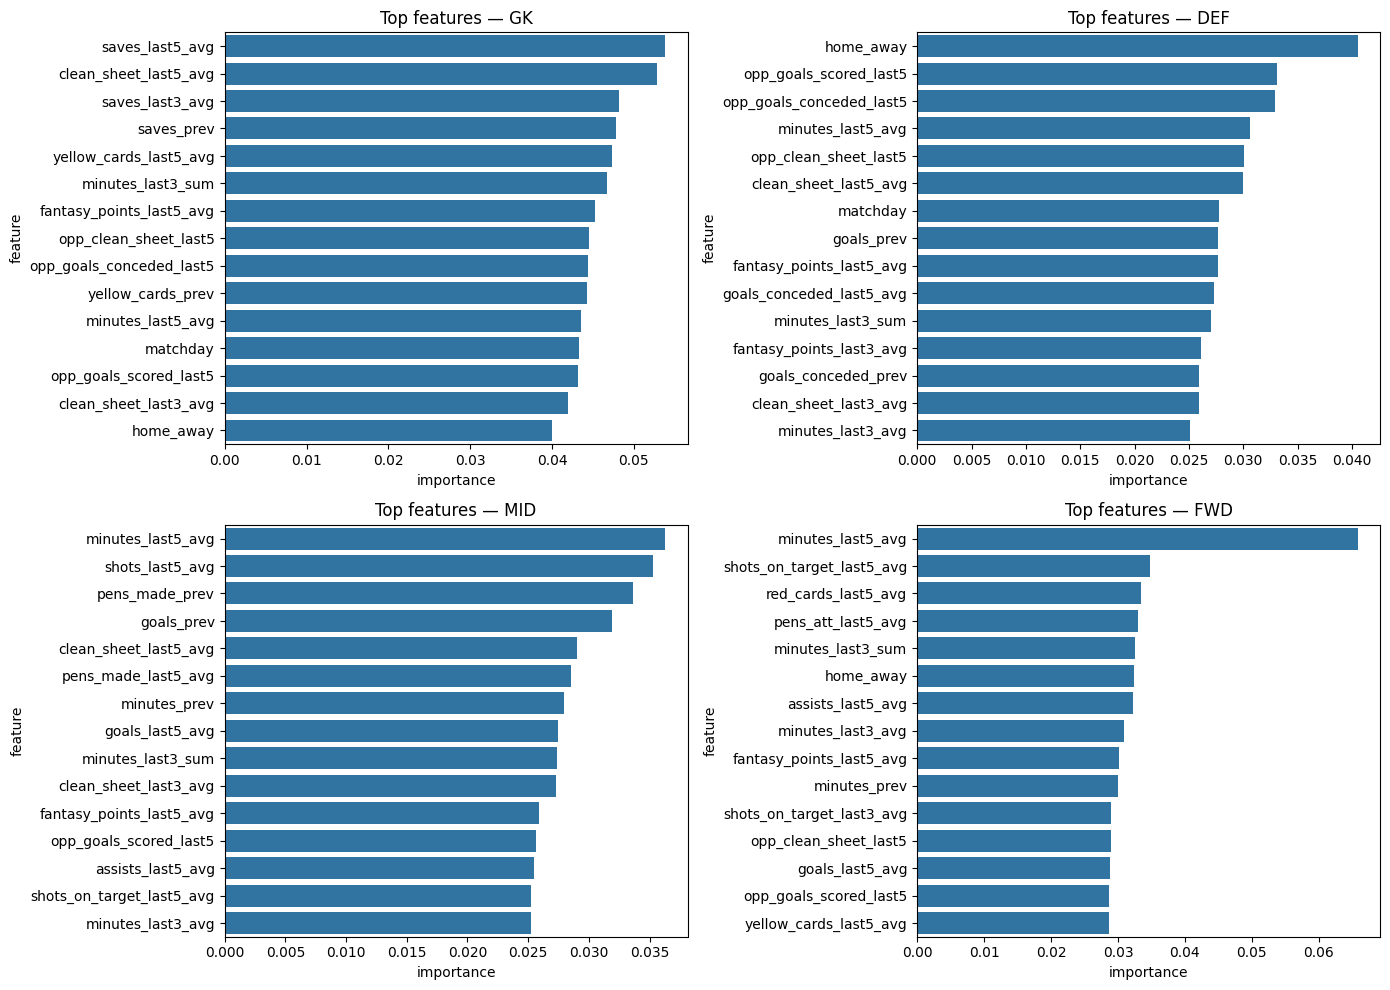

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (pos, m) in zip(axes.flat, models.items()):                                                                                                                                                   
    imp_df = pd.DataFrame({                                                                                                                                                                           
    
        "feature":    splits[pos][0].columns,
        "importance": m.feature_importances_,                                                                                                                                                         
    
    }).sort_values("importance", ascending=False).head(15)                                                                                                                                          
    
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax)                                                                                                                                      
    
    ax.set_title(f"Top features — {pos}")                                                                                                                                                           

plt.tight_layout()                                                                                                                                                                                    

plt.show()      

In [17]:
# see example predictions 

X_tr, X_te, y_tr, y_te = splits[pos]                                                                                                                                                                  

pred = models[pos].predict(X_te)                                                                                                                                                                      
                                                                                                                                                                                                        
bucket_names = {0: "none", 1: "low", 2: "standout"}                                                                                                                                            
                                                                                                                                                                                                        
mask = df_sorted["fantasy_position"] == pos                                                                                                                                                           

df_pos = df_sorted[mask].reset_index(drop=True)                                                                                                                                                       

split_idx = int(len(df_pos) * 0.8)             

df_test = df_pos.iloc[split_idx:].reset_index(drop=True)                                                                                                                                              
                                                          
results = pd.DataFrame({                                                                                                                                                                              
    "player": df_test["player"],
    "opponent": df_test["opponent"],                                                                                                                                                             
    "date": df_test["date"],                                                                                                                                                                 
    "actual_pts": df_test["fantasy_points"],
    "actual_bucket": [bucket_names[b] for b in y_te],                                                                                                                                                 
    "predicted": [bucket_names[b] for b in pred],                                                                                                                                                 
})                                                   

results.sample(20, random_state=1)                     

,player,opponent,date,actual_pts,actual_bucket,predicted
354,Elif Elmas,Benfica pt,2025-12-10,2,low,none
473,Ivan Schranz,es Barcelona,2026-01-21,1,none,none
372,Lautaro Martínez,eng Arsenal,2026-01-20,2,low,standout
576,João Pedro,Napoli it,2026-01-28,10,standout,none
8,Brennan Johnson,dk FC Copenhagen,2025-11-04,3,low,none
799,Julián Álvarez,Tottenham Hotspur eng,2026-03-18,9,standout,standout
579,Tomáš Chorý,Pafos FC cy,2026-01-28,1,none,none
247,Ange-Yoan Bonny,eng Liverpool,2025-12-09,1,none,none
265,Elye Wahi,Barcelona es,2025-12-09,1,none,none
493,Dominic Solanke,Eintracht Frankfurt de,2026-01-28,5,standout,standout


In [18]:
# examples where the model predicted a standout
results[results["predicted"] == "standout"].head(20)

,player,opponent,date,actual_pts,actual_bucket,predicted
5,Jordan Larsson,Tottenham Hotspur eng,2025-11-04,1,none,standout
11,Ayoub El Kaabi,nl PSV,2025-11-04,2,low,standout
14,Vinicius Júnior,Liverpool eng,2025-11-04,1,none,standout
15,Harry Kane,Paris Saint-Germain fr,2025-11-04,2,low,standout
20,Rasmus Højlund,de Eintracht Frankfurt,2025-11-04,2,low,standout
24,Ousmane Dembélé,de Bayern Munich,2025-11-04,1,none,standout
28,Guus Til,Olympiacos gr,2025-11-04,1,none,standout
30,Promise David,Atlético Madrid es,2025-11-04,1,none,standout
33,Bukayo Saka,Slavia Prague cz,2025-11-04,6,standout,standout
36,Richarlison,dk FC Copenhagen,2025-11-04,1,none,standout


Confusion matrix heatmap

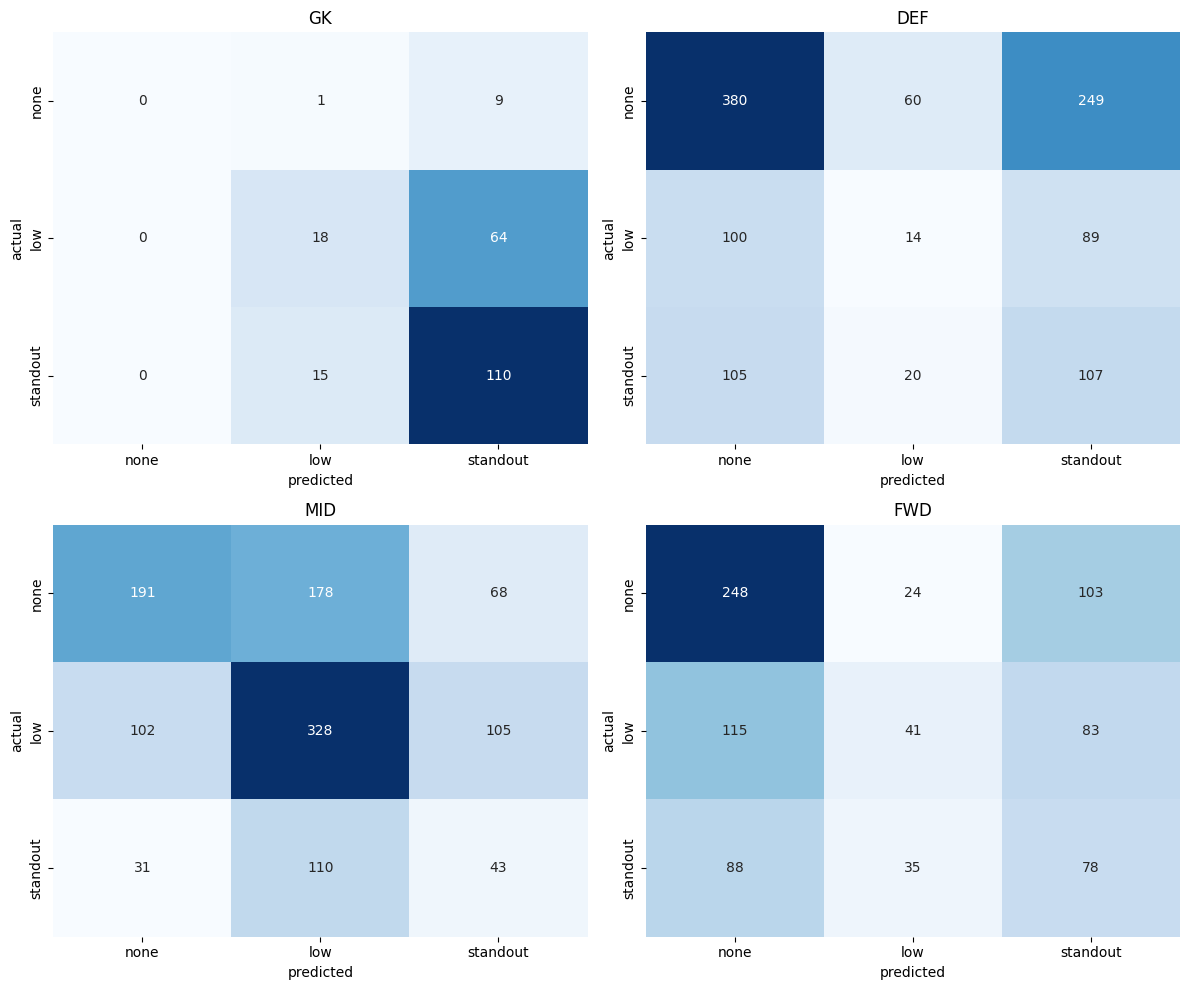

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))                                                                                                                                                      

labels = ["none", "low", "standout"]        

for ax, (pos, m) in zip(axes.flat, models.items()):                                                                                                                                                   
    X_tr, X_te, y_tr, y_te = splits[pos]                                                                                                                                                              
    cm = confusion_matrix(y_te, m.predict(X_te))                                                                                                                                                      
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",                                                                                                                                                
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)                                                                                                                            
    ax.set_title(f"{pos}")                                                                                                                                                                            
    ax.set_xlabel("predicted")                                                                                                                                                                        
    ax.set_ylabel("actual")                                                                                                                                                                           

plt.tight_layout()         

plt.show()    

Point distribution per position (chart of our data)

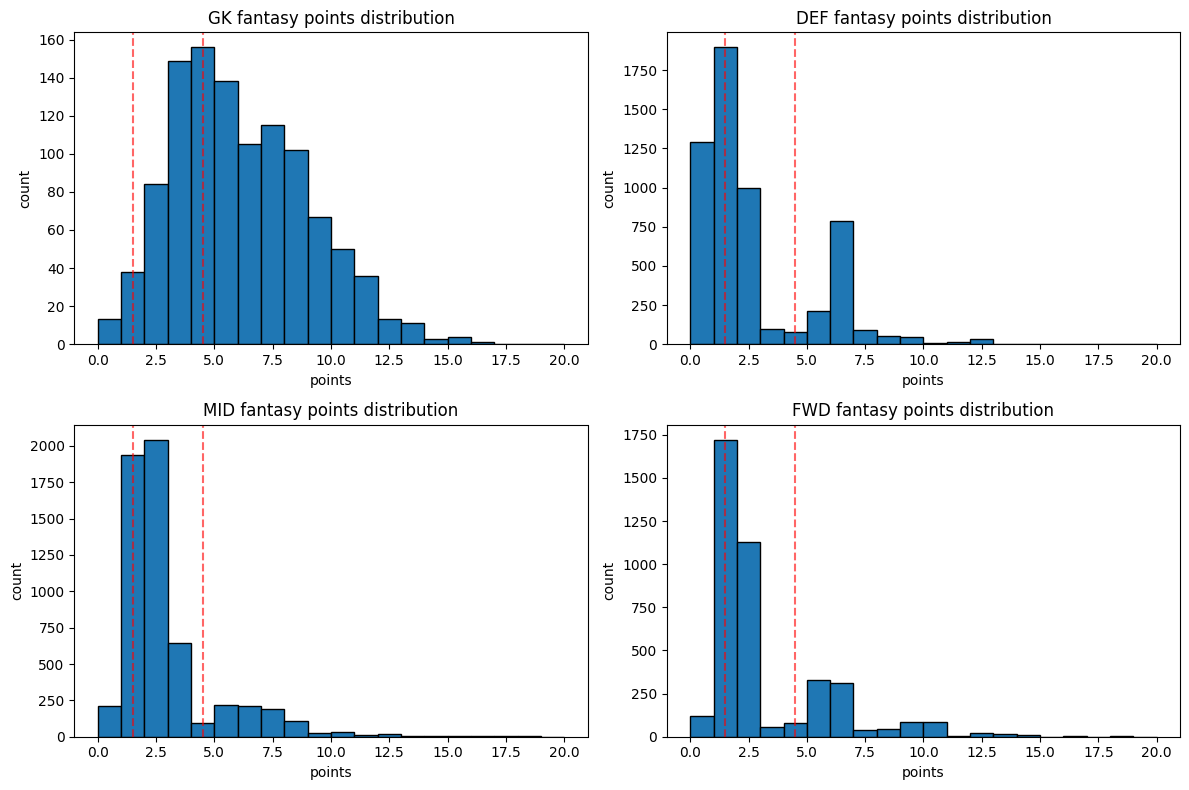

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))                                                                                                                                     

for ax, pos in zip(axes.flat, ["GK","DEF","MID","FWD"]):                                                                                                                            
    
    pts = df[df["fantasy_position"] == pos]["fantasy_points"].clip(lower=0)
    
    ax.hist(pts, bins=range(0, 21), edgecolor="black")

    for cut in [1, 4]:                                
        ax.axvline(cut + 0.5, color="red", linestyle="--", alpha=0.6)                                                                                                               

    ax.set_title(f"{pos} fantasy points distribution")                                                                                                                              

    ax.set_xlabel("points")                                                                                                                                                         

    ax.set_ylabel("count")                                                                                                                                                          

plt.tight_layout()        

plt.show()   

Predicted standout probability distribution chart

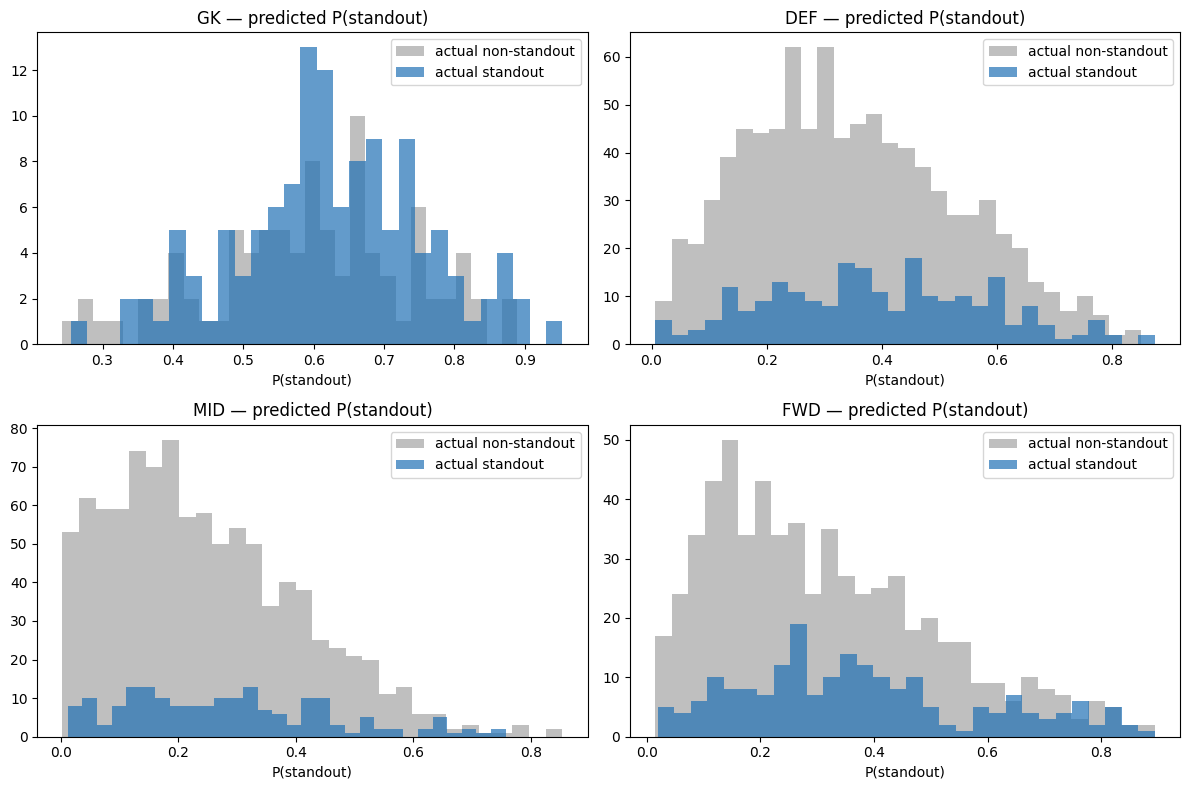

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (pos, m) in zip(axes.flat, models.items()):                                                                                                                                 
    
    X_tr, X_te, y_tr, y_te = splits[pos]           
    
    proba = m.predict_proba(X_te)[:, 2]                                                                                                                                             
    
    actual_standout = (y_te == 2)       
    
    ax.hist(proba[~actual_standout], bins=30, alpha=0.5, label="actual non-standout", color="gray")
    
    ax.hist(proba[actual_standout],  bins=30, alpha=0.7, label="actual standout", color="#2171b5")                                                                                  
    
    ax.set_title(f"{pos} — predicted P(standout)")                                                
    
    ax.set_xlabel("P(standout)")                                                                                                                                                    
    
    ax.legend()                             

plt.tight_layout()                                                                                                                                                                  

plt.show() 

Standout recall and precision per position visualization

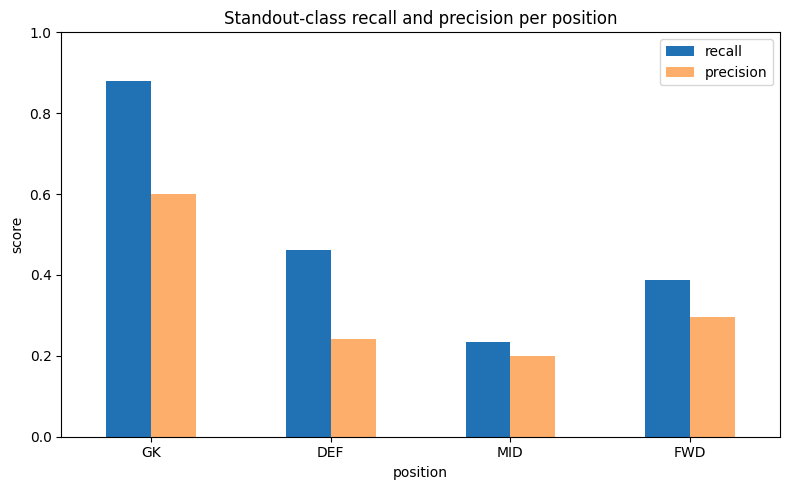

In [22]:
metrics = []

for pos, m in models.items():                                                                                                                                                       
    
    X_tr, X_te, y_tr, y_te = splits[pos]
    
    pred = m.predict(X_te)                                                                                                                                                          
    
    metrics.append({                        
          "position": pos,                
          "recall":    recall_score(y_te, pred, labels=[2], average="macro", zero_division=0),
          "precision": precision_score(y_te, pred, labels=[2], average="macro", zero_division=0),                                                                                     
    })                                                                                         
  
md = pd.DataFrame(metrics).set_index("position")                                                                                                                                    

md.plot(kind="bar", figsize=(8,5), color=["#2171b5","#fdae6b"])

plt.title("Standout-class recall and precision per position")                                                                                                                       

plt.ylabel("score")                                          

plt.xticks(rotation=0)                                                                                                                                                              

plt.ylim(0, 1)                                                                                                                                                                      

plt.tight_layout()                      

plt.show()     

Print standout recall, precision, and lift per position

In [28]:
print(f"{'pos':<5} {'recall':>8} {'precision':>11} {'base':>8} {'lift':>6}")

for pos, m in models.items():                                               
    X_tr, X_te, y_tr, y_te = splits[pos]
    
    pred = m.predict(X_te)                                                  
    
    recall = recall_score(y_te, pred, labels=[2], average="macro", zero_division=0)
    
    precision = precision_score(y_te, pred, labels=[2], average="macro", zero_division=0)                            
    
    base = (y_te == 2).mean()                                               
    
    lift = recall / base
    
    print(f"{pos:<5} {recall:>8.3f} {precision:>11.3f} {base:>8.3f} {lift:>5.2f}x")  

pos     recall   precision     base   lift
GK       0.880       0.601    0.576  1.53x
DEF      0.461       0.240    0.206  2.23x
MID      0.234       0.199    0.159  1.47x
FWD      0.388       0.295    0.247  1.57x
